/var/folders/rt/3260sfx57rj4s3lg0trkqvgw0000gn/T/ipykernel_72263/1091057650.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/anaconda3/envs/sentiment/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


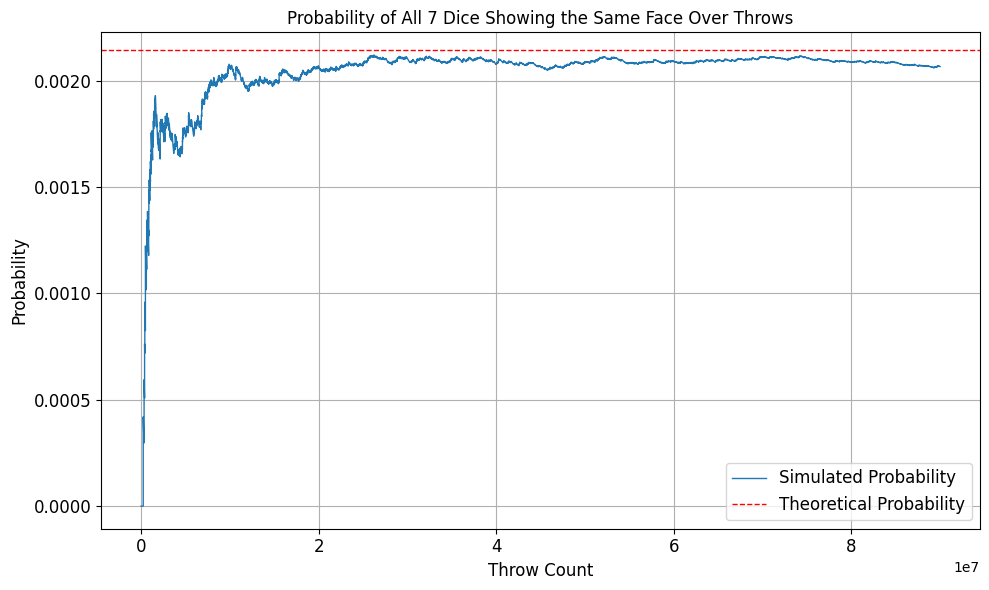

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dice.txt')
df.columns = df.columns.str.strip()

theoretical_prob = 1 / (6 ** 6) * 100  # ≈ 0.0000214 * 100

plt.figure(figsize=(10, 6))

plt.plot(df['throw_count'], df['percentage'], linestyle='-', linewidth=1, label='Simulated Probability')
plt.axhline(y=theoretical_prob, color='red', linestyle='--', linewidth=1, label='Theoretical Probability')

plt.xlabel('Throw Count', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Probability of All 7 Dice Showing the Same Face Over Throws', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()



   index  radius      x      y  withinCount  percentageWithin  theoretical
0      0     7.0 -7.000 -5.158            0          0.000000     0.785398
1      1     7.0  3.578 -0.579            1          0.500000     0.785398
2      2     7.0  0.459 -3.935            2          0.666667     0.785398
3      3     7.0 -6.341  2.504            3          0.750000     0.785398
4      4     7.0  2.510  6.086            4          0.800000     0.785398


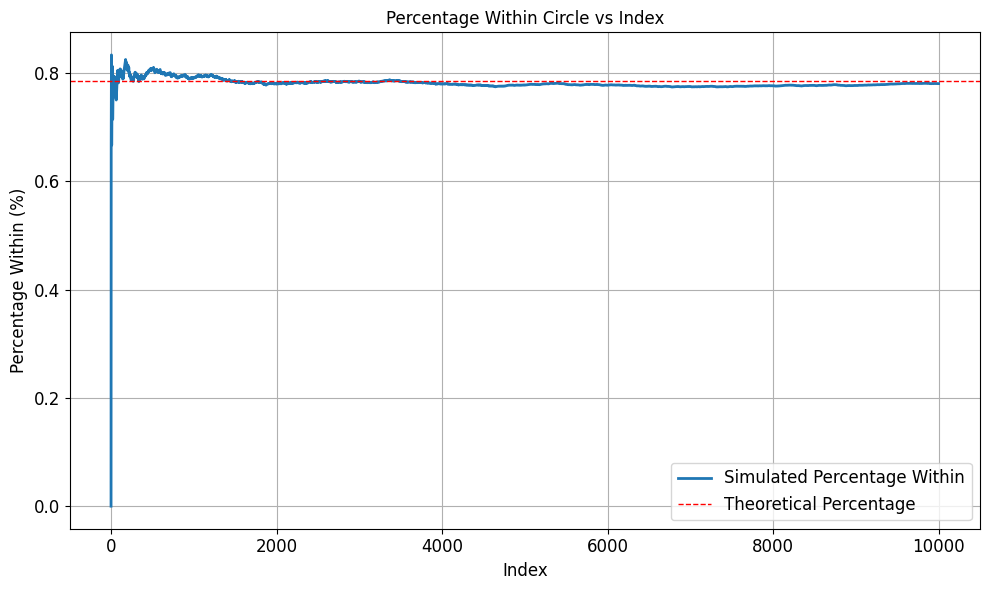

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Assign proper column names according to your data
cols = ['index', 'radius', 'x', 'y', 'withinCount', 'percentageWithin', 'theoretical']

# Read CSV, skip first row, use cols for headers
df = pd.read_csv('test.txt', skiprows=1, names=cols)

# Inspect to verify
print(df.head())

# Plot percentageWithin over index (or x/y as you want)
plt.figure(figsize=(10, 6))

plt.plot(df['index'], df['percentageWithin'], linestyle='-', linewidth=2, label='Simulated Percentage Within')

plt.axhline(y=df['theoretical'][0], color='red', linestyle='--', linewidth=1, label='Theoretical Percentage')

plt.xlabel('Index', fontsize=12)
plt.ylabel('Percentage Within (%)', fontsize=12)
plt.title('Percentage Within Circle vs Index', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


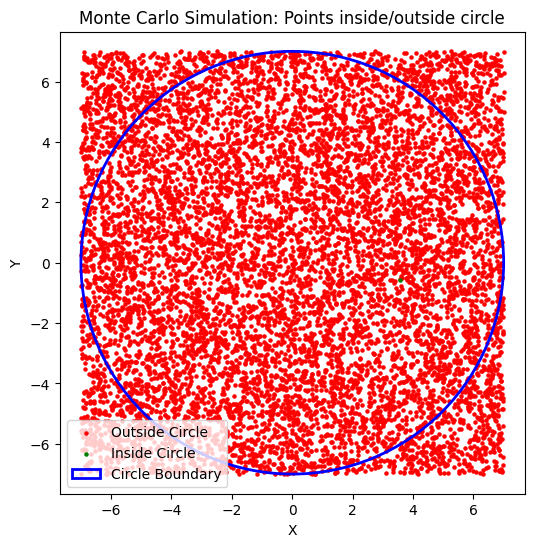

In [11]:
import matplotlib.pyplot as plt

# Load CSV data: columns = index,radius,x,y,withinCount,percentageWithin,theoretical
filename = "test.txt"

x_in, y_in = [], []
x_out, y_out = [], []

with open(filename, 'r') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 7:
            continue

        x = float(parts[2])
        y = float(parts[3])
        is_within = int(parts[4])

        if is_within == 1:
            x_in.append(x)
            y_in.append(y)
        else:
            x_out.append(x)
            y_out.append(y)

# Plot points
plt.figure(figsize=(6,6))
plt.scatter(x_out, y_out, color='red', s=5, label='Outside Circle')
plt.scatter(x_in, y_in, color='green', s=5, label='Inside Circle')

# Draw the circle boundary
radius = max(max(abs(x) for x in x_in + x_out), max(abs(y) for y in y_in + y_out))
circle = plt.Circle((0, 0), radius, color='blue', fill=False, linewidth=2, label='Circle Boundary')
plt.gca().add_artist(circle)

plt.axis('equal')
plt.legend()
plt.title('Monte Carlo Simulation: Points inside/outside circle')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
